# Day 13 — Seaborn Visualization
Seaborn builds on Matplotlib, works directly with DataFrames, and looks polished by default.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Boxplot of age by passenger class
Spot the **outliers** (dots beyond the whiskers) and compare **medians** (the line inside each box).

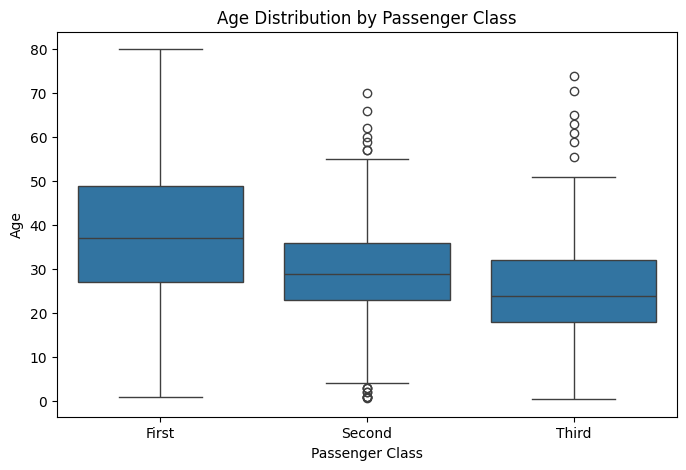

In [2]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="class", y="age", data=df)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

## 2. Countplot of survivors vs non-survivors, split by sex
`hue="sex"` automatically creates side-by-side colored bars — no extra code needed.

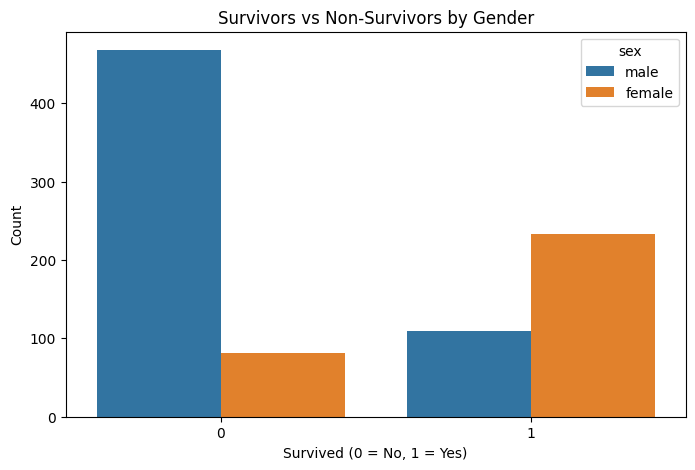

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x="survived", hue="sex", data=df)
plt.title("Survivors vs Non-Survivors by Gender")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

## 3. Histplot of fares with a KDE overlay
`kde=True` adds the smooth density curve on top of the histogram bars.

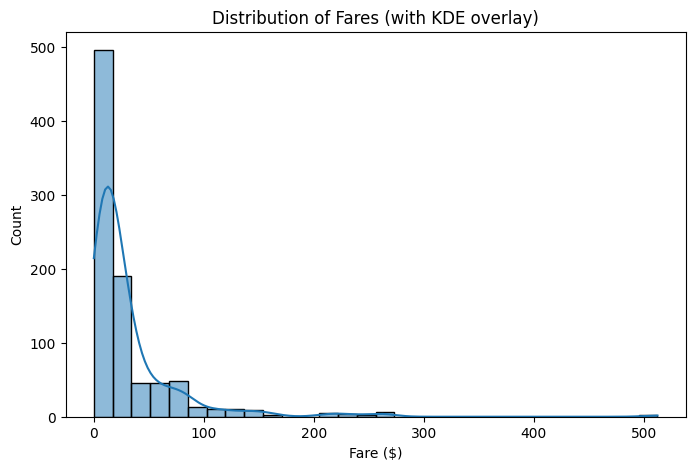

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], bins=30, kde=True)
plt.title("Distribution of Fares (with KDE overlay)")
plt.xlabel("Fare ($)")
plt.ylabel("Count")
plt.show()

## 4. Violinplot of age distribution by survival status
Like a boxplot but shows the full shape — wider sections mean more passengers at that age.

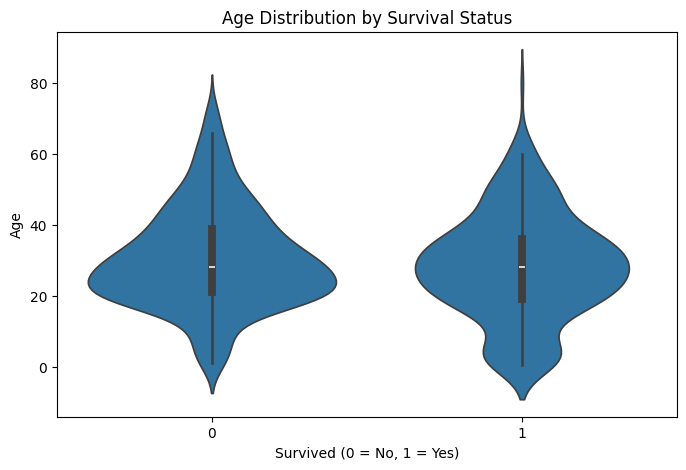

In [5]:
plt.figure(figsize=(8, 5))
sns.violinplot(x="survived", y="age", data=df)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

## 5. Scatterplot of age vs fare, colored by survived
`hue="survived"` automatically colors each dot by survival status.

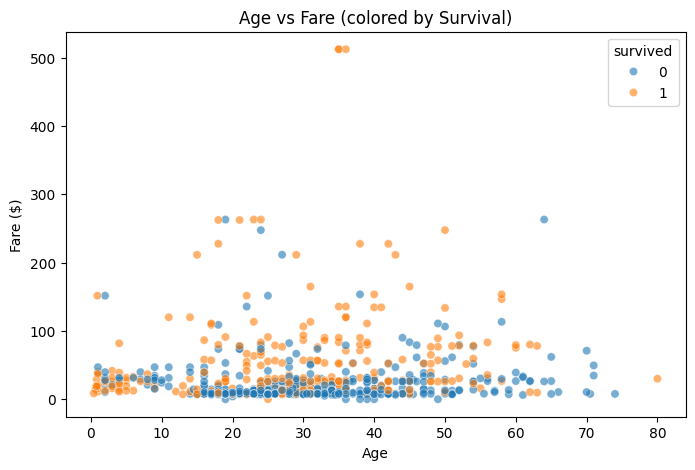

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="fare", hue="survived", data=df, alpha=0.6)
plt.title("Age vs Fare (colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.show()

## 6. Correlation Heatmap
Read the `survived` row — which variables correlate most with survival?
- Values close to **+1** or **-1** = strong relationship
- Values close to **0** = no relationship

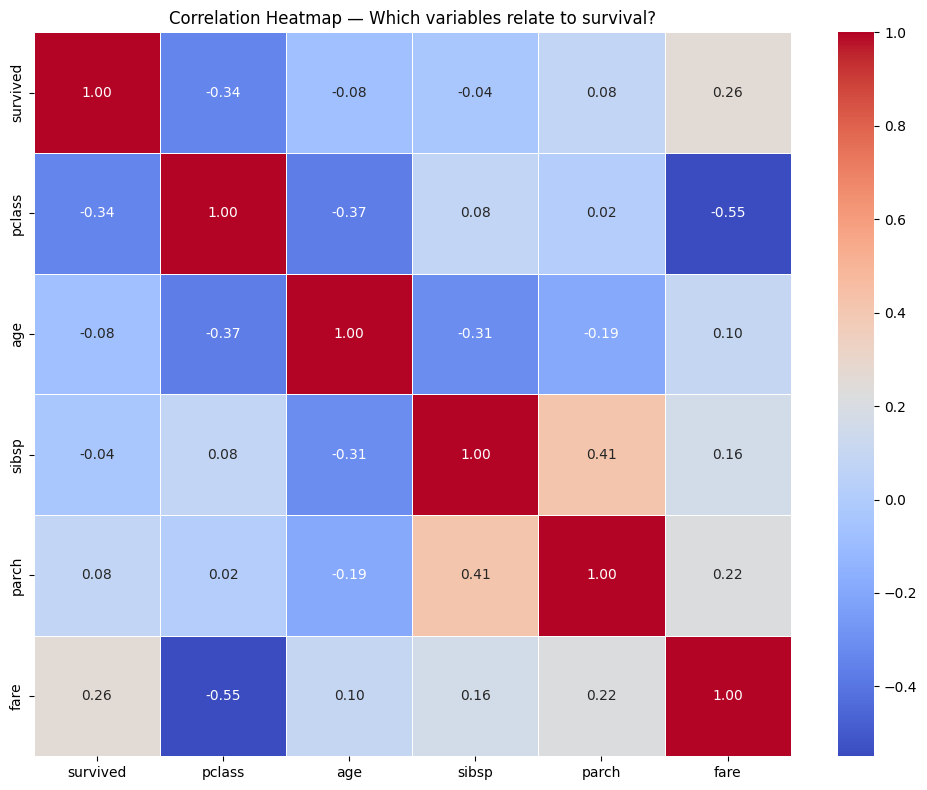

In [7]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Which variables relate to survival?")
plt.tight_layout()
plt.show()

## 7. Mini-challenge: Matplotlib vs Seaborn comparison
Yesterday's "Survival Rate by Class" bar chart recreated in Seaborn.

**Matplotlib version (Day 12)** needed ~5 lines:
```python
survival_by_class = df.groupby("class")["survived"].mean()
plt.bar(survival_by_class.index, survival_by_class.values, color=[...])
plt.title(...)
plt.xlabel(...)
plt.ylabel(...)
```

**Seaborn version** — one line does the grouping, mean, AND error bars. Plus `hue="sex"` adds a whole extra dimension for free!

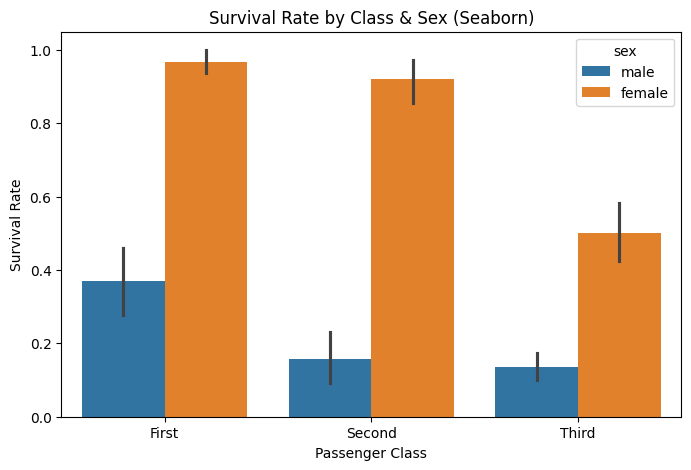

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x="class", y="survived", hue="sex", data=df)
plt.title("Survival Rate by Class & Sex (Seaborn)")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()